In [1]:
import pickle
import time
import warnings
import matplotlib.pyplot as plt
import numpy as np
import scipy.sparse
import shapely
import tqdm
import quadpy
from pathlib import Path
import warnings
from random_matrix.amplitude_matrix import (
    isotropic_sphere,
    scattering_geometry,
)
from random_matrix.input_statistics import density_function, density_integrals
from random_matrix.input_statistics.density_function import (
    DeltaDensityFactor,
    DensityFunction,
    DensityFunctionTerm,
    RegularDensityFactor,
)
from random_matrix.input_statistics.index_finder import IndexFinder
from random_matrix.input_statistics.input_statistics_manager import (
    InputStatisticsManager,
)
from random_matrix.input_statistics.integration_task import (
    IntegrationTaskPreparer,
    IntegrationTaskConfig,
)
from random_matrix.input_statistics.medium_parameters import MediumParameters
from random_matrix.input_statistics.medium_statistics import (
    MediumStatistics,
    ParticleStatistics,
)
from random_matrix.modes import mode_grid, mode_grid_factory
from random_matrix.utils import (
    array_utils,
    function_utils,
    geometry_utils,
    integration_utils,
    matrix_utils,
    special_functions,
)
from random_matrix.scattering_matrix import sampler

In [2]:
DATA_DIR_FILENAME = Path("/home/nbyrnes/code/random-matrix/paper_data/data")
MODE_GRIDS_FILENAME = Path(
    "/home/nbyrnes/code/random-matrix/paper_data/mode_grids_rectangular.pkl"
)
TWO_NP_PREAMBLE = "2d_np_rectangular_midpoint_"
THREE_NP_PREAMBLE = "3d_np_rectangular_midpoint_"
TWO_CP_PREAMBLE = "2d_cp_rectangular_midpoint_"
THREE_CP_PREAMBLE = "3d_cp_rectangular_midpoint_"

if MODE_GRIDS_FILENAME.exists():
    # Load existing mode grids
    with MODE_GRIDS_FILENAME.open("rb") as f:
        mode_grids = pickle.load(f)
        num_modes = [m.num_propagating for m in mode_grids]

two_np_paths = [
    DATA_DIR_FILENAME / f"{TWO_NP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]
three_np_paths = [
    DATA_DIR_FILENAME / f"{THREE_NP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]
two_cp_paths = [
    DATA_DIR_FILENAME / f"{TWO_CP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]
three_cp_paths = [
    DATA_DIR_FILENAME / f"{THREE_CP_PREAMBLE}{n}/integration_result_list.pkl"
    for n in num_modes
]

two_np_results = []
three_np_results = []
two_cp_results = []
three_cp_results = []

for p in two_np_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            two_np_results.append(results)
for p in three_np_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            three_np_results.append(results)
for p in two_cp_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            two_cp_results.append(results)
for p in three_cp_paths:
    if p.exists():
        with p.open("rb") as f:
            results = pickle.load(f)
            three_cp_results.append(results)

### Covariance

In [ ]:
cov_results_two_np = [
    r.by_statistic_type("covariance") for r in two_np_results
]
cov_results_three_np = [
    r.by_statistic_type("covariance") for r in three_np_results
]
cov_results_two_cp = [
    r.by_statistic_type("covariance") for r in two_cp_results
]
cov_results_three_cp = [
    r.by_statistic_type("covariance") for r in three_cp_results
]

In [8]:
print(cov_results_two_np[0].results[0].block_location[1])
print(cov_results_two_np[0].results[0].sub_block_locations[0])

t,t
(-50, -50, -50, -50)


In [18]:
def results_to_dict(results, block="t,t"):
    return {
        r.sub_block_locations[0]: r.integral
        for r in results
        if r.sub_block_locations and r.block_location[1] == block
    }


cov_two_np_t = [
    results_to_dict(result_list.results, "t,t")
    for result_list in cov_results_two_np
]
cov_two_np_r = [
    results_to_dict(result_list.results, "r,r")
    for result_list in cov_results_two_np
]
cov_two_np_r2 = [
    results_to_dict(result_list.results, "r2,r2")
    for result_list in cov_results_two_np
]


cov_three_np_t = [
    results_to_dict(result_list.results, "t,t")
    for result_list in cov_results_three_np
]
cov_three_np_r = [
    results_to_dict(result_list.results, "r,r")
    for result_list in cov_results_three_np
]
cov_three_n_r2 = [
    results_to_dict(result_list.results, "r2,r")
    for result_list in cov_results_three_np
]

### Central cov

In [ ]:
central_cov_two_np = [dic[0, 0, 0, 0].reshape(4, 4) for dic in cov_two_np_t]
central_cov_three_np = [
    dic[0, 0, 0, 0].reshape(9, 9) for dic in cov_three_np_t
]

In [58]:
# Get the infinitesimal matrix (ground truth?)
wavelength = 550e-9
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

# Mean product term
A = isotropic_sphere.get_A(
    np.array([0.0]),
    np.array([0.0]),
    np.array([1.0]),
    np.array([0.0]),
    np.array([0.0]),
    np.array([1.0]),
    np.array([2.0]),
    np.array([1.2]),
)
prod = np.outer(A, np.conj(A)).reshape(4, 4)
scaled = prod*(medium_parameters.cov_const_factor - medium_parameters.mean_const_factor**2)
ground_truth = np.linalg.norm(scaled)
print(ground_truth)

0.015035506713404572


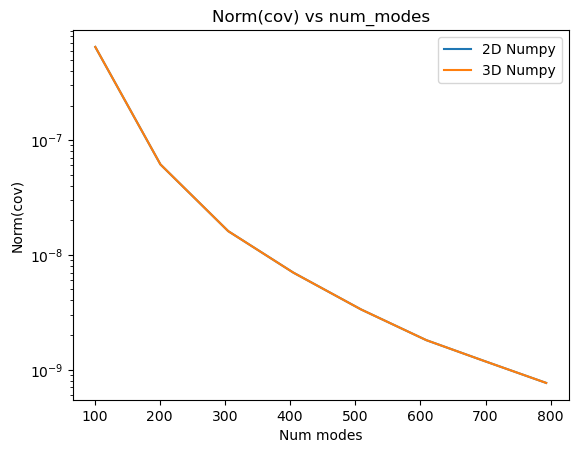

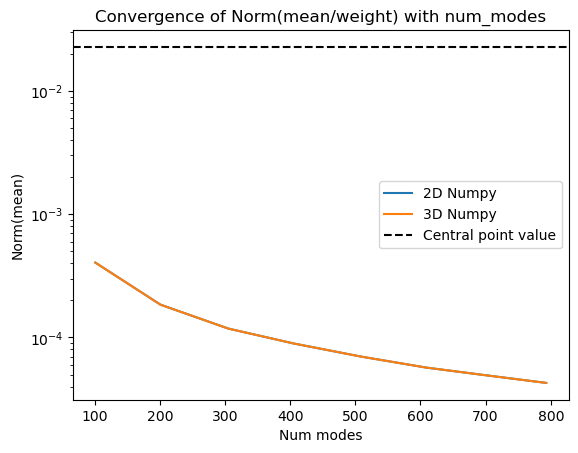

In [ ]:
end_index_two = len(central_cov_two_np)
end_index_three = len(central_cov_three_np)

y1 = [np.linalg.norm(cov) for cov in central_cov_two_np]
y2 = [
    np.linalg.norm(cov / mode_grid.by_index(0).weight ** 2)
    for cov, mode_grid in zip(central_cov_two_np, mode_grids[0:end_index_two])
]

y3 = [np.linalg.norm(cov) for cov in central_cov_three_np]
y4 = [
    np.linalg.norm(cov / mode_grid.by_index(0).weight ** 2)
    for cov, mode_grid in zip(
        central_cov_three_np, mode_grids[0:end_index_three]
    )
]


# min_vals = [
#     np.min(np.abs(np.linalg.eigvals(mat))) for mat in central_cov_three_np
# ]
# max_vals = [
#     np.max(np.abs(np.linalg.eigvals(mat))) for mat in central_mean_three_np
# ]
# y5 = np.array(min_vals) / np.array(max_vals)

# min_vals_normalized = [
#     np.min(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
#     for mat, mode_grid in zip(central_mean_three_np, mode_grids)
# ]
# max_vals_normalized = [
#     np.max(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
#     for mat, mode_grid in zip(central_mean_three_np, mode_grids)
# ]
# y6 = np.array(min_vals_normalized) / np.array(max_vals_normalized)


fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y1, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y3, label="3D Numpy")
ax.set_ylabel("Norm(cov)")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Norm(cov) vs num_modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y2, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y4, label="3D Numpy")
ax.axhline(
    y=ground_truth, color="black", linestyle="--", label="Central point value"
)
ax.set_ylabel("Norm(mean)")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Convergence of Norm(mean/weight) with num_modes")
ax.legend()

# fig, ax = plt.subplots()
# ax.plot(
#     np.array(num_modes)[0:end_index_three], max_vals, label="Max eigenvalue"
# )
# ax.plot(
#     np.array(num_modes)[0:end_index_three], min_vals, label="Min eigenvalue"
# )
# ax.set_ylabel("Norm")
# ax.set_xlabel("Num modes")
# ax.set_yscale("log")
# ax.set_title("Norm(eigenvalue)")
# ax.legend()

# fig, ax = plt.subplots()
# ax.plot(np.array(num_modes)[0:end_index_three], y5, label="3D Numpy")
# ax.set_ylabel("Norm(ratio)")
# ax.set_xlabel("Num modes")
# ax.set_title("Abs(third eigenvalue)/mean(abs(other two))")

# fig, ax = plt.subplots()
# ax.plot(
#     np.array(num_modes)[0:end_index_three], max_vals_normalized, label="Max eigenvalue"
# )
# ax.plot(
#     np.array(num_modes)[0:end_index_three], min_vals_normalized, label="Min eigenvalue"
# )
# ax.set_ylabel("Norm")
# ax.set_xlabel("Num modes")
# ax.set_yscale("log")
# ax.set_title("Norm(eigenvalue normalized)")
# ax.legend()

### Central mode in reflection

In [ ]:
print(mean_two_np_r[0][0, 0])
print(mean_two_np_t[0][0, 0])

[[-1.72256969e-06-1.06318814e-06j -1.47830277e-25+6.30081967e-26j
   1.47830277e-25-6.30081967e-26j  1.79263000e-06+1.03186007e-06j]]
[[ 5.23599689e-04-2.44338947e-03j  0.00000000e+00+0.00000000e+00j
  -1.04359087e-38+1.59295157e-36j  5.23599689e-04-2.44338947e-03j]]


In [10]:
central_mean_two_np = [dic[0, 0].reshape(2, 2) for dic in mean_two_np_r]
central_mean_three_np = [dic[0, 0].reshape(3, 3) for dic in mean_three_np_r]

In [ ]:
# Get the infinitesimal matrix (ground truth?)
wavelength = 550e-9
k = 2 * np.pi / wavelength
slab_thickness = 1.8992695221776513e-06
number_density = 5.921762640653617e17
medium_parameters = MediumParameters(
    wavelength=wavelength,
    number_density=number_density,
    slab_thickness=slab_thickness,
)
term = DensityFunctionTerm.from_delta({"x": 2.0, "m": 1.2})

A = (
    isotropic_sphere.get_A(
        np.array([0.0]),
        np.array([0.0]),
        np.array([1.0]),
        np.array([0.0]),
        np.array([0.0]),
        np.array([-1.0]),
        np.array([2.0]),
        np.array([1.2]),
    )
    * medium_parameters.mean_const_factor
    * np.sin(k * slab_thickness)
    / (k * slab_thickness)
)
print(A.reshape(2, 2))
ground_truth = np.linalg.norm(A)
print(ground_truth)

[[ 3.50982315e-05+2.35420388e-05j  0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j -3.50982315e-05-2.35420388e-05j]]
5.9768109330593984e-05


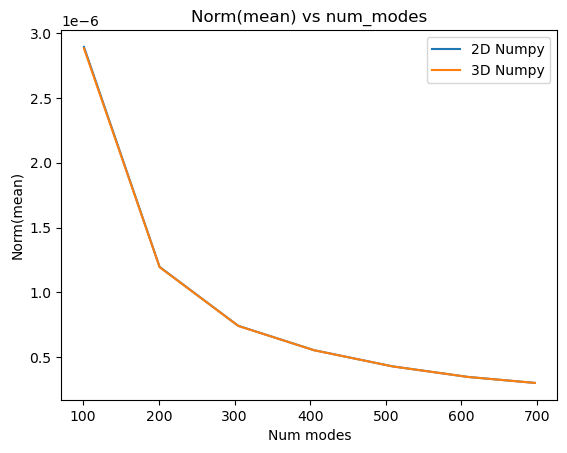

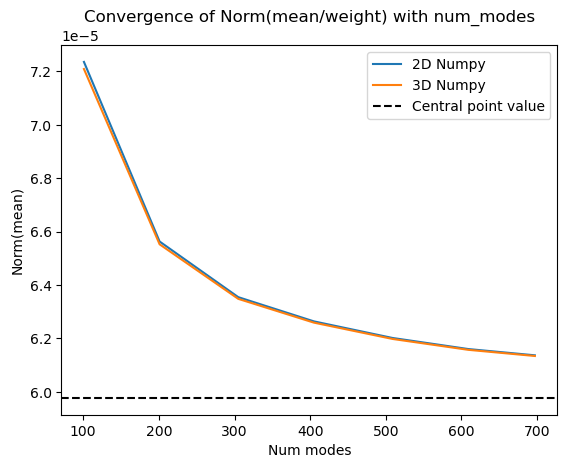

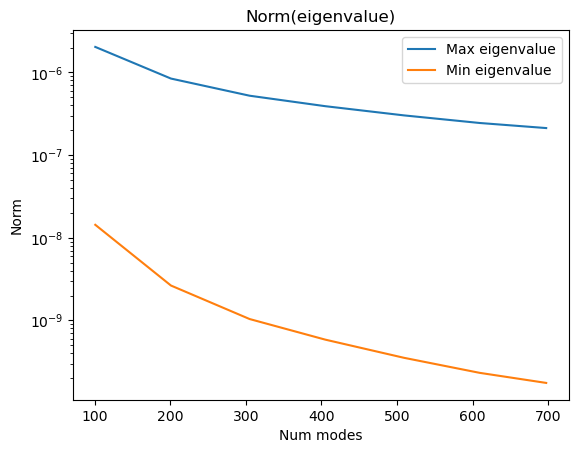

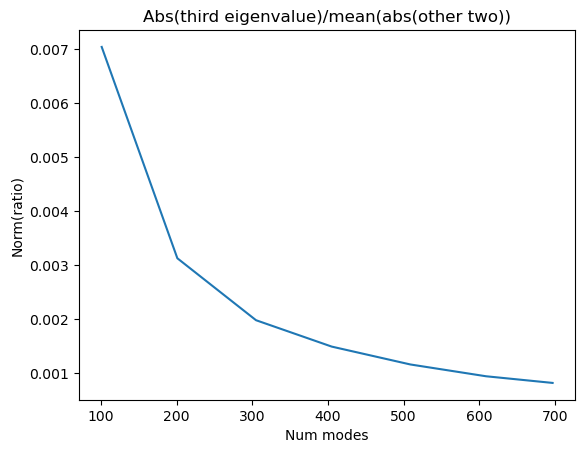

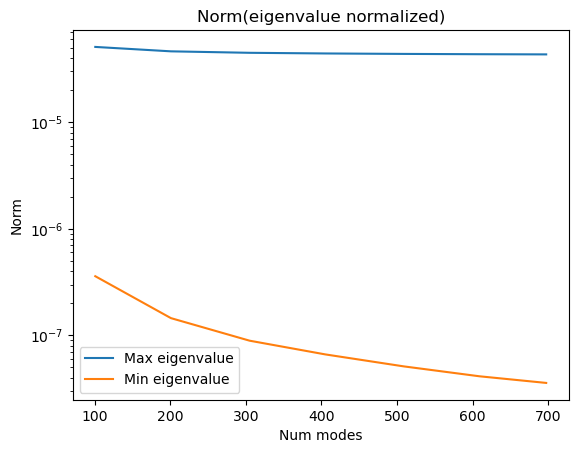

In [ ]:
end_index_two = len(central_mean_two_np)
end_index_three = len(central_mean_three_np)

y1 = [np.linalg.norm(mean) for mean in central_mean_two_np]
y2 = [
    np.linalg.norm(mean / mode_grid.by_index(0).weight)
    for mean, mode_grid in zip(
        central_mean_two_np, mode_grids[0:end_index_two]
    )
]

y3 = [np.linalg.norm(mean) for mean in central_mean_three_np]
y4 = [
    np.linalg.norm(mean / mode_grid.by_index(0).weight)
    for mean, mode_grid in zip(
        central_mean_three_np, mode_grids[0:end_index_three]
    )
]


min_vals = [
    np.min(np.abs(np.linalg.eigvals(mat))) for mat in central_mean_three_np
]
max_vals = [
    np.max(np.abs(np.linalg.eigvals(mat))) for mat in central_mean_three_np
]
y5 = np.array(min_vals) / np.array(max_vals)

min_vals_normalized = [
    np.min(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
    for mat, mode_grid in zip(central_mean_three_np, mode_grids)
]
max_vals_normalized = [
    np.max(np.abs(np.linalg.eigvals(mat / mode_grid.by_index(0).weight)))
    for mat, mode_grid in zip(central_mean_three_np, mode_grids)
]
y6 = np.array(min_vals_normalized) / np.array(max_vals_normalized)


fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y1, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y3, label="3D Numpy")
ax.set_ylabel("Norm(mean)")
ax.set_xlabel("Num modes")
ax.set_title("Norm(mean) vs num_modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_two], y2, label="2D Numpy")
ax.plot(np.array(num_modes)[0:end_index_three], y4, label="3D Numpy")
ax.axhline(
    y=ground_truth, color="black", linestyle="--", label="Central point value"
)
ax.set_ylabel("Norm(mean)")
ax.set_xlabel("Num modes")
ax.set_title("Convergence of Norm(mean/weight) with num_modes")
ax.legend()

fig, ax = plt.subplots()
ax.plot(
    np.array(num_modes)[0:end_index_three], max_vals, label="Max eigenvalue"
)
ax.plot(
    np.array(num_modes)[0:end_index_three], min_vals, label="Min eigenvalue"
)
ax.set_ylabel("Norm")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Norm(eigenvalue)")
ax.legend()

fig, ax = plt.subplots()
ax.plot(np.array(num_modes)[0:end_index_three], y5, label="3D Numpy")
ax.set_ylabel("Norm(ratio)")
ax.set_xlabel("Num modes")
ax.set_title("Abs(third eigenvalue)/mean(abs(other two))")

fig, ax = plt.subplots()
ax.plot(
    np.array(num_modes)[0:end_index_three],
    max_vals_normalized,
    label="Max eigenvalue",
)
ax.plot(
    np.array(num_modes)[0:end_index_three],
    min_vals_normalized,
    label="Min eigenvalue",
)
ax.set_ylabel("Norm")
ax.set_xlabel("Num modes")
ax.set_yscale("log")
ax.set_title("Norm(eigenvalue normalized)")
ax.legend()